In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Dataset
print("Loading dataset...")
df = pd.read_csv('/Users/duncanpark/10-faers-foundation-model/data/processed/faers_combined_cleaned_pure_reactions.csv')

Loading dataset...


In [4]:
# Count each row
print("Calculating counts per patient...")

def count_elements(text):
    if pd.isna(text) or str(text).strip() == "":
        return 0
    return len([item for item in str(text).split(';') if item.strip()])

# Apply counting function to every patient case row
df['drug_count'] = df['drug_combination'].apply(count_elements)
df['adr_count'] = df['adrs'].apply(count_elements)

Calculating counts per patient...


In [5]:
mean_drugs = df['drug_count'].mean()
median_drugs = df['drug_count'].median()
mode_drugs = df['drug_count'].mode()[0]

mean_adrs = df['adr_count'].mean()
median_adrs = df['adr_count'].median()
mode_adrs = df['adr_count'].mode()[0]

print("\n--- DRUG STATS PER PATIENT ---")
print(f"Mean (Average):   {mean_drugs:.2f}")
print(f"Median (Typical): {median_drugs:.1f}")
print(f"Mode (Most Freq): {mode_drugs}")

print("\n--- SIDE EFFECT (ADR) STATS PER PATIENT ---")
print(f"Mean (Average):   {mean_adrs:.2f}")
print(f"Median (Typical): {median_adrs:.1f}")
print(f"Mode (Most Freq): {mode_adrs}")


--- DRUG STATS PER PATIENT ---
Mean (Average):   3.41
Median (Typical): 1.0
Mode (Most Freq): 1

--- SIDE EFFECT (ADR) STATS PER PATIENT ---
Mean (Average):   3.14
Median (Typical): 2.0
Mode (Most Freq): 1



Generating charts...


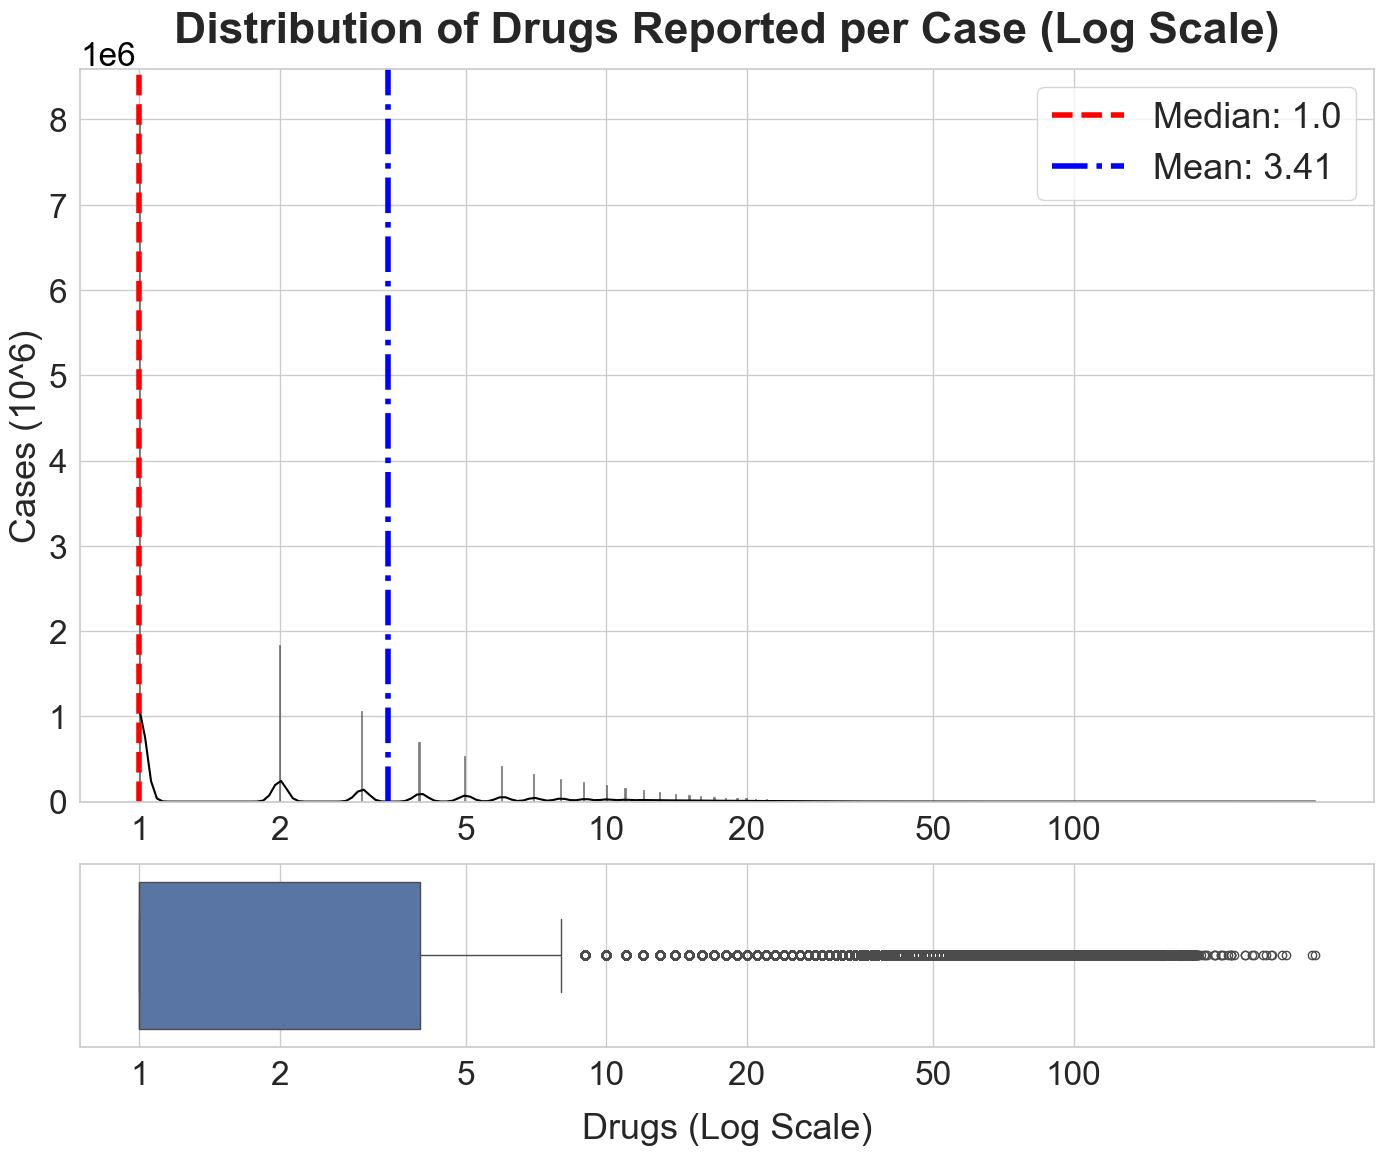

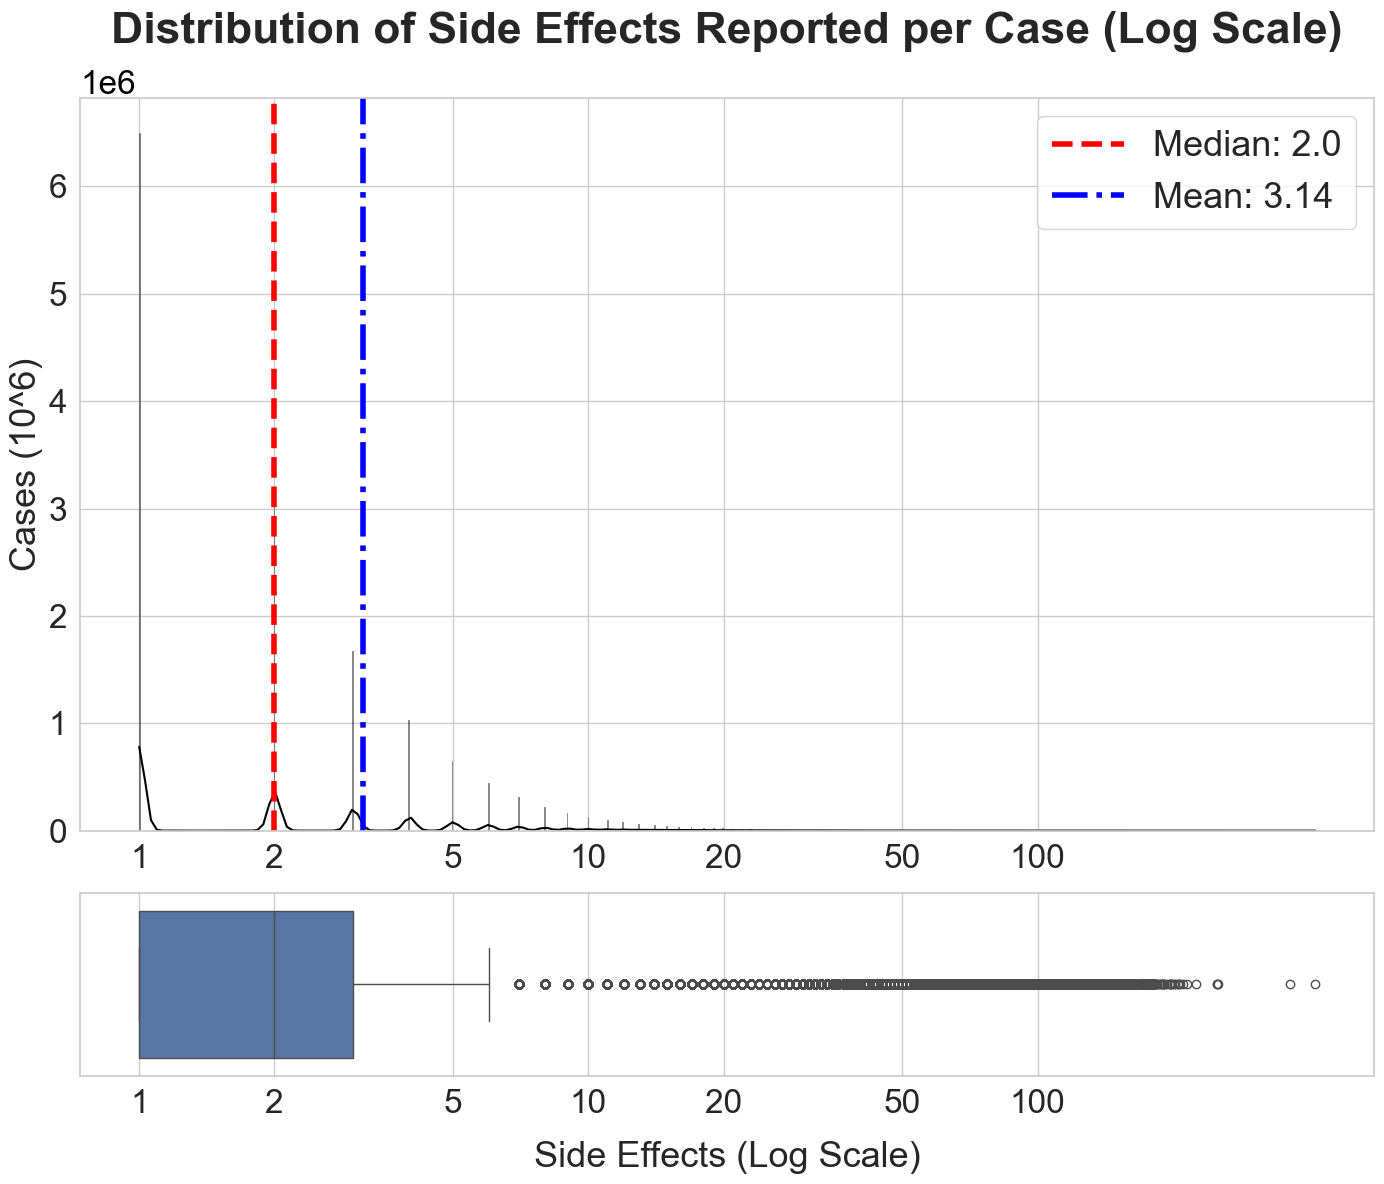

In [15]:
from matplotlib.ticker import ScalarFormatter

print("\nGenerating charts...")
sns.set_theme(style="whitegrid")

df_drugs_filtered = df[df['drug_count'] > 0]
df_adr_filtered = df[df['adr_count'] > 0]

# ==========================================
# CHART 1: DRUG DISTRIBUTION (LOG SCALE)
# ==========================================
fig1, axes1 = plt.subplots(2, 1, figsize=(14, 12), gridspec_kw={"height_ratios": (.8, .2)})

# --- A. Drug Distribution Histogram ---
sns.histplot(data=df_drugs_filtered, x='drug_count', log_scale=True,
             kde=True, color='#000000', ax=axes1[0])
axes1[0].set_title('Distribution of Drugs Reported per Case (Log Scale)', fontsize=32, fontweight='bold', pad=20)
axes1[0].set_xlabel('')
axes1[0].set_ylabel('Cases (10^6)', fontsize=26)
axes1[0].tick_params(labelsize=24)

# Add Mean Line (Blue) and Median Line (Red)
axes1[0].axvline(median_drugs, color='red', linestyle='--', linewidth=4, label=f"Median: {median_drugs:.1f}")
axes1[0].axvline(mean_drugs, color='blue', linestyle='-.', linewidth=4, label=f"Mean: {mean_drugs:.2f}")
axes1[0].legend(fontsize=26)

# --- A. Drug Distribution Box Plot ---
sns.boxplot(data=df_drugs_filtered, x='drug_count', ax=axes1[1])
axes1[1].set_xscale('log')
axes1[1].set_xlabel('Drugs (Log Scale)', fontsize=26, labelpad=15)
axes1[1].tick_params(labelsize=24)

# Clean up ticks to display as whole numbers instead of scientific powers of 10
for ax in axes1:
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.set_xticks([1, 2, 5, 10, 20, 50, 100])

# Scientific notation formatting on the Y-axis of the top plot
axes1[0].ticklabel_format(style='sci', axis='y', scilimits=(6,6))
offset_text1 = axes1[0].yaxis.get_offset_text()
offset_text1.set_fontsize(24)
offset_text1.set_color('#000000')

fig1.tight_layout()
# fig1.savefig('drugs_distribution_separated.png', dpi=300) # Un-comment to save
plt.show()


# ==========================================
# CHART 2: SIDE EFFECT DISTRIBUTION (LOG SCALE)
# ==========================================
fig2, axes2 = plt.subplots(2, 1, figsize=(14, 12), gridspec_kw={"height_ratios": (.8, .2)})

# --- B. Side Effect Distribution Histogram ---
sns.histplot(data=df_adr_filtered, x='adr_count', log_scale=True, 
             kde=True, color='#000000', ax=axes2[0])
axes2[0].set_title('Distribution of Side Effects Reported per Case (Log Scale)', fontsize=32, fontweight='bold', pad=20)
axes2[0].set_xlabel('')
axes2[0].set_ylabel('Cases (10^6)', fontsize=26) # Added label back since it's a standalone plot
axes2[0].tick_params(labelsize=24)

# Add Mean Line (Blue) and Median Line (Red)
axes2[0].axvline(median_adrs, color='red', linestyle='--', linewidth=4, label=f"Median: {median_adrs:.1f}")
axes2[0].axvline(mean_adrs, color='blue', linestyle='-.', linewidth=4, label=f"Mean: {mean_adrs:.2f}")
axes2[0].legend(fontsize=26)

# --- B. Side Effect Distribution Box Plot ---
sns.boxplot(data=df_adr_filtered, x='adr_count', ax=axes2[1])
axes2[1].set_xscale('log')
axes2[1].set_xlabel('Side Effects (Log Scale)', fontsize=26, labelpad=15)
axes2[1].tick_params(labelsize=24)

# Clean up ticks to display as whole numbers instead of scientific powers of 10
for ax in axes2:
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.set_xticks([1, 2, 5, 10, 20, 50, 100])

# Scientific notation formatting on the Y-axis of the top plot
axes2[0].ticklabel_format(style='sci', axis='y', scilimits=(6,6))
offset_text2 = axes2[0].yaxis.get_offset_text()
offset_text2.set_fontsize(24)
offset_text2.set_color('#000000')

fig2.tight_layout()
# fig2.savefig('adr_distribution_separated.png', dpi=300) # Un-comment to save
plt.show()